In [1]:
import os
import sys
current_dir = os.path.dirname(os.path.abspath('.'))
project_root = os.path.abspath(os.path.join(current_dir, "../.."))
sys.path.insert(0, project_root)

In [2]:
import yaml
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LinearRegression
from mlxtend.feature_selection import SequentialFeatureSelector as SFS

import warnings
warnings.filterwarnings('ignore')

In [3]:
with open(os.path.join("../config/config.yaml"), "r") as f:
    config = yaml.safe_load(f)
        
with open(os.path.join( "../config/pipeline.yaml"), "r") as f:
    config_pipe = yaml.safe_load(f)  

with open(os.path.join("../config/model.yaml"), "r") as f:
    config_model = yaml.safe_load(f)

In [4]:
X_train = pd.read_parquet(
        os.path.join(
            config['init_path'],
            config['data']['feature_eng'],
            "X_train_feat_eng_pipeline1.parquet"))
y_train = pd.read_parquet(
        os.path.join(
            config['init_path'],
            config['data']['feature_eng'],
            "Y_train_feat_eng_pipeline1.parquet"))

In [5]:
X_train.drop(
            columns=config_model['single_model']['cols_2_drop'],
            inplace=True)
        
# X_val.drop(
#             columns=config_model['single_model']['cols_2_drop'],
#             inplace=True)   


In [7]:
sfs = SFS(
    estimator=LinearRegression(),
    k_features=X_train.shape[1]-1,  
    forward=True,  
    floating=False,  
    scoring='neg_mean_squared_error',
    cv=5, 
    n_jobs=-1
    )  

In [8]:
sfs_pipe = make_pipeline(sfs)
sfs_fit = sfs_pipe.fit(X_train, y_train)
    
results = pd.DataFrame.from_dict(sfs_pipe.named_steps['sequentialfeatureselector'].subsets_).T

In [9]:
results

,feature_idx,cv_scores,avg_score,feature_names
1,"(6,)","[-2634908636.817218, -2048566236.0665503, -273...",-2294266486.648765,"(num_dis_pipe__OverallQual,)"
2,"(1, 6)","[-2019303287.0963137, -1862444413.4076889, -23...",-1843606944.985531,"(num_con_1_pipe__GrLivArea, num_dis_pipe__Over..."
3,"(1, 6, 20)","[-1602509906.6736238, -1636719745.459705, -210...",-1554575477.786085,"(num_con_1_pipe__GrLivArea, num_dis_pipe__Over..."
4,"(1, 3, 6, 20)","[-1526189770.4315052, -1480231240.665676, -211...",-1481041451.082316,"(num_con_1_pipe__GrLivArea, num_con_2_pipe__Bs..."
5,"(0, 1, 3, 6, 20)","[-1513701845.626617, -1407844185.5482495, -205...",-1421320420.433215,"(num_con_1_pipe__LotArea, num_con_1_pipe__GrLi..."
6,"(0, 1, 3, 6, 12, 20)","[-1460882022.9057531, -1289888180.3732722, -19...",-1351304852.498141,"(num_con_1_pipe__LotArea, num_con_1_pipe__GrLi..."
7,"(0, 1, 3, 6, 12, 15, 20)","[-1439530941.1676383, -1280190632.2204647, -18...",-1326470922.35197,"(num_con_1_pipe__LotArea, num_con_1_pipe__GrLi..."
8,"(0, 1, 3, 6, 8, 12, 15, 20)","[-1437265956.9013762, -1253707154.1176226, -18...",-1306736482.876871,"(num_con_1_pipe__LotArea, num_con_1_pipe__GrLi..."
9,"(0, 1, 3, 6, 8, 9, 12, 15, 20)","[-1417602237.8240907, -1277876527.6740549, -18...",-1298619386.788937,"(num_con_1_pipe__LotArea, num_con_1_pipe__GrLi..."
10,"(0, 1, 3, 6, 7, 8, 9, 12, 15, 20)","[-1402606398.138889, -1313021950.7998917, -185...",-1290069072.388396,"(num_con_1_pipe__LotArea, num_con_1_pipe__GrLi..."


In [10]:
metric_dict = sfs.get_metric_dict()
num_features = list(metric_dict.keys())
avg_scores = [metric_dict[k]['avg_score'] for k in num_features]
std_scores = [metric_dict[k]['std_dev'] for k in num_features]
cv_scores = [metric_dict[k]['cv_scores'] for k in num_features]  # Scores individuais de cada fold

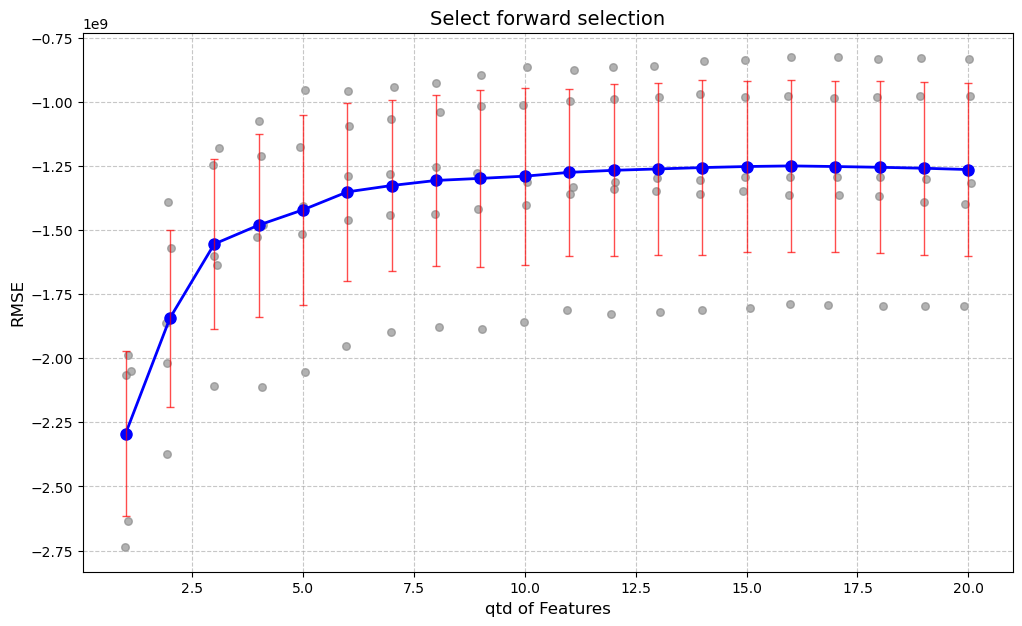

In [11]:
plt.figure(figsize=(12, 7))
plt.plot(
    num_features, 
    avg_scores, 
    marker='o', 
    linestyle='-', 
    color='b', 
    linewidth=2,
    markersize=8)

# Adicionar barras de erro (desvio padrão)
plt.errorbar(
    num_features, 
    avg_scores, 
    yerr=std_scores, 
    fmt='none', 
    ecolor='red', 
    elinewidth=1, 
    capsize=3, 
    alpha=0.7)

# Adicionar pontos individuais de cada fold da validação cruzada
for i, n in enumerate(num_features):
    # Espalhar os pontos horizontalmente para melhor visualização
    x_positions = np.random.normal(n, 0.05, size=len(cv_scores[i]))
    plt.scatter(x_positions, cv_scores[i], color='gray', alpha=0.6, s=30)

plt.xlabel('qtd of Features', fontsize=12)
plt.ylabel('RMSE', fontsize=12)
plt.title('Select forward selection', fontsize=14)
plt.grid(True, linestyle='--', alpha=0.7)
